# Generate high-resolution colorized images from the original downloaded astrocyte Martone images.

#### Load grayscale astrocyte images, increases their resolution, apply an inferno colormap, and save the processed images

In [4]:
# Create High Resolution Color Images for Astrocytes

import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage import morphology


input_folder = "Downloaded_Images"
output_folder = "Hi_Res_Images_Colorized"
os.makedirs(output_folder, exist_ok=True)

# Resolution Factor for High Res Images
scale_factor = 4  

# Function to auto-crop borders
def auto_crop(image, threshold=5):
    """ Auto-crop non-black areas of an image """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)  
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(np.concatenate(contours))  
        cropped_image = image[y:y+h, x:x+w] 
        return cropped_image
    return image  

# Process all images
image_files = sorted([f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.tif'))])

for img_name in image_files:
    image_path = os.path.join(input_folder, img_name)
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray_image is None:
        print(f"Skipping {img_name}: Could not load image.")
        continue

    # Increase resolution
    high_res_gray = cv2.resize(gray_image, (0, 0), fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

    # Apply colormap for visibility
    color_image = cv2.applyColorMap(high_res_gray, cv2.COLORMAP_INFERNO)
    cropped_image = auto_crop(color_image)
    output_path = os.path.join(output_folder, f"{os.path.splitext(img_name)[0]}_hi_res_colorized.png")
    cv2.imwrite(output_path, cropped_image)
    print(f"Processed and saved: {output_path}")

print("All images processed and saved successfully!")


Processed and saved: Hi_Res_Images_Colorized/astro_1_hi_res_colorized.png
Processed and saved: Hi_Res_Images_Colorized/astro_2_hi_res_colorized.png
Processed and saved: Hi_Res_Images_Colorized/astro_3_hi_res_colorized.png
All images processed and saved successfully!


#### Create binary masks for soma, thick branches, and thin processes using intensity thresholds and save each mask as a separate image.

In [5]:

import tarfile
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage import morphology

#==================================================================
# Create Soma, Thick Branch and Thin Processes Masks
#==================================================================

input_folder = "Hi_Res_Images_Colorized"
output_folder = "Masks_For_Healthy"
os.makedirs(output_folder, exist_ok=True)

# Threshold values, identified using ImageJ Thresholding
thresholds = {
    "soma": 210,
    "thick": 135,
    "thin": 50
}

image_files = sorted([f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.tif'))])

# Generate Region Masks (Refer to Block Diagram #1)
def filter_soma_region(binary_mask):
    """Keeps only the largest bright region (assumed to be soma) and removes other regions."""
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        filtered_mask = np.zeros_like(binary_mask)
        cv2.drawContours(filtered_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
        return filtered_mask
    return binary_mask 

def filter_thick_branches(binary_mask):
    # Remove small regions (thin processes)
    min_size = 500
    filtered_mask = morphology.remove_small_objects(binary_mask.astype(bool), min_size=min_size).astype(np.uint8) * 255
    return filtered_mask

# Process each image in a loop
for idx, img_name in enumerate(image_files, start=1):
    image_path = os.path.join(input_folder, img_name)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    for label, thresh in thresholds.items():
        binary_mask = np.where(image >= thresh, 255, 0).astype(np.uint8)
        if label == "soma":
            binary_mask = filter_soma_region(binary_mask)
            
        if label == "thick":
            binary_mask = filter_thick_branches(binary_mask)
        output_name = f"{idx}_{label}_mask.png"
        output_path = os.path.join(output_folder, output_name)
        cv2.imwrite(output_path, binary_mask)
    print(f"Processed {img_name}")

print("All images processed and saved successfully!")


Processed astro_1_hi_res_colorized.png
Processed astro_2_hi_res_colorized.png
Processed astro_3_hi_res_colorized.png
All images processed and saved successfully!


#### Load the individual soma, thick-branch, and thin-process masks, combine them into one labeled array assigning each pixel a region label, save the final .npy segmentation map, and visualize each region separately.


 Final Unique Values in Labeled Array: {0: 397733, 1: 483037, 2: 1668352, 3: 15158142}

 Step_0_Stitched_NPYs/Healthy_astro_1_stitched.npy file saved.


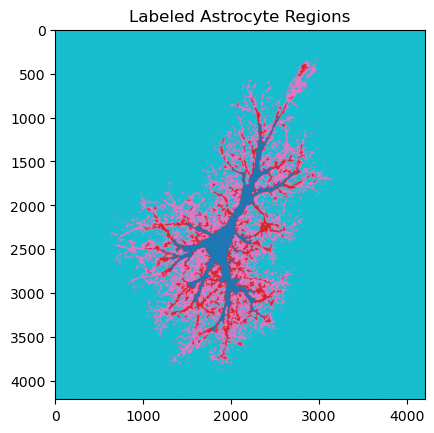

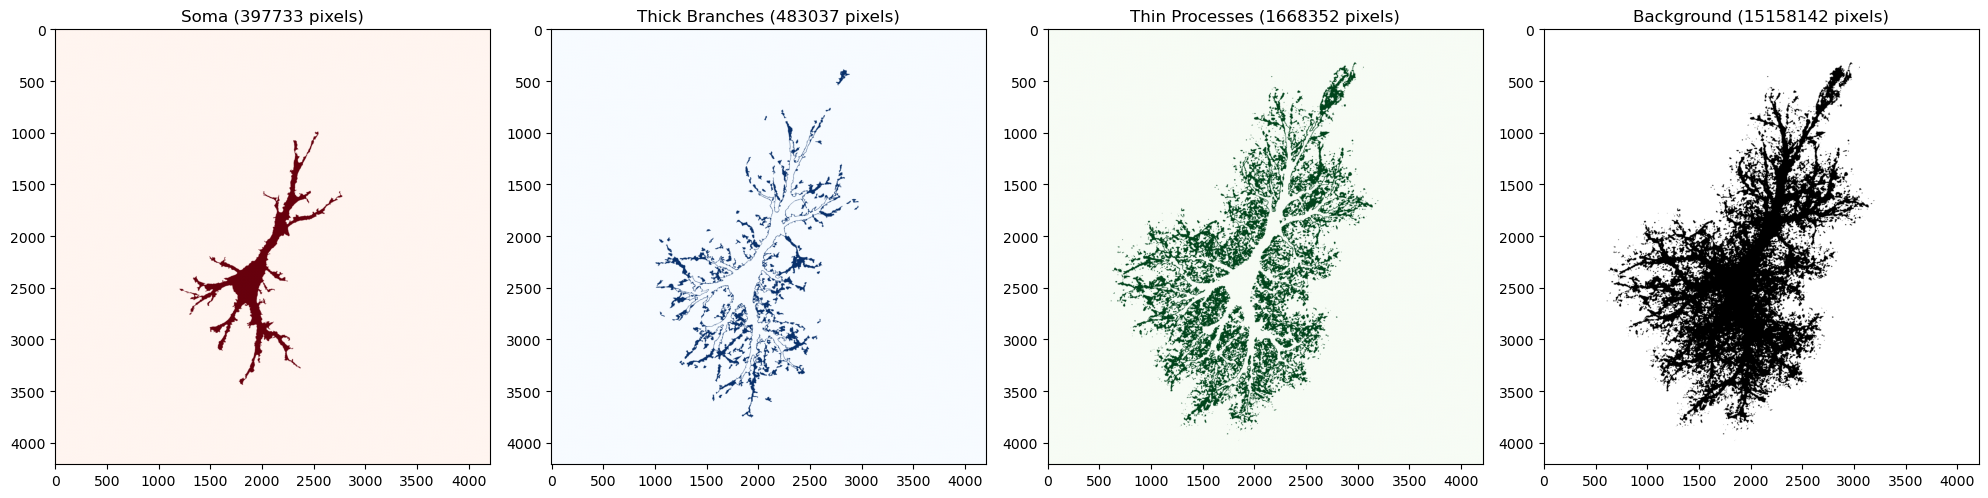

In [6]:
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt

stitch_dir = "Step_0_Stitched_NPYs"
os.makedirs(stitch_dir, exist_ok=True)

# ========================================
# Load Individual Region Masks
# ========================================
soma_mask = imread("Masks_For_Healthy/1_soma_mask.png") > 0
thick_branch_mask = imread("Masks_For_Healthy/1_thick_mask.png") > 0
thin_process_mask = imread("Masks_For_Healthy/1_thin_mask.png") > 0

# =====================================================
# Initialize Labeled Array with Background
# =====================================================
labeled_array = np.full_like(soma_mask, fill_value=3, dtype=int)  # Set all pixels to Background

# Assign Soma first (highest priority)
labeled_array[soma_mask] = 0
# Assign Thick Branches next, ensuring it does NOT overwrite Soma
labeled_array[(thick_branch_mask) & (labeled_array == 3)] = 1
# Correct Thin Process Mask: Remove Soma, Thick, and Background from Thin
only_thin_mask = thin_process_mask & (labeled_array == 3)  # Thin should only be in unassigned pixels
# Assign Thin Processes last (only in valid pixels)
labeled_array[only_thin_mask] = 2

# ========================================
# Verify Unique Labels Before Saving
# ========================================
unique_values, counts = np.unique(labeled_array, return_counts=True)
print("\n Final Unique Values in Labeled Array:", dict(zip(unique_values, counts)))

# If Any Label Is Missing, STOP and Debug
expected_labels = {0, 1, 2, 3}
if set(unique_values) != expected_labels:
    missing_labels = expected_labels - set(unique_values)
    raise ValueError(f"🚨 ERROR: Missing labels {missing_labels} after assignment! Debug before proceeding.")

# ========================================
# Save as `.npy` File
# ========================================
output_name = "Healthy_astro_1_stitched.npy"
output_path = os.path.join(stitch_dir, output_name)

#np.save("Healthy_astro_1_stitched.npy", labeled_array)
np.save(output_path, labeled_array)
print("\n Step_0_Stitched_NPYs/Healthy_astro_1_stitched.npy file saved.")

# ========================================
# Visualize the Labeled Array
# ========================================
plt.imshow(labeled_array, cmap='tab10')
plt.title("Labeled Astrocyte Regions")
plt.show()

# =====================================================
# Extract & Visualize Each Region Separately**
# =====================================================
soma_mask = labeled_array == 0
thick_branch_mask = labeled_array == 1
thin_process_mask = labeled_array == 2
background_mask = labeled_array == 3  # Explicitly defined background

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# Soma
axs[0].imshow(soma_mask, cmap="Reds")
axs[0].set_title(f"Soma ({np.sum(soma_mask)} pixels)")

# Thick Branches
axs[1].imshow(thick_branch_mask, cmap="Blues")
axs[1].set_title(f"Thick Branches ({np.sum(thick_branch_mask)} pixels)")

# Thin Processes
axs[2].imshow(thin_process_mask, cmap="Greens")
axs[2].set_title(f"Thin Processes ({np.sum(thin_process_mask)} pixels)")

# Background
axs[3].imshow(background_mask, cmap="gray")
axs[3].set_title(f"Background ({np.sum(background_mask)} pixels)")

plt.tight_layout()
plt.show()
